# Pixel Art Generation with a Tiny Diffusion Model
**DLAI- 2025/2026**  
Chosen topic from guidelines: `Image/Video Generation`  

---
### Project Summary
We train a **class-conditional** DDPM (Denoising Diffusion Probabilistic Model) on 89,400 pixel art sprites.
The model generates novel pixel art conditioned on one of 5 sprite categories:
- **Category 0**: Characters (no weapon) — 8,000 images
- **Category 1**: Fruits & round objects — 32,400 images
- **Category 2**: Large fruits — 6,000 images
- **Category 3**: Armors & arrows — 35,000 images
- **Category 4**: Characters (with weapon) — 8,000 images

**Dataset**: [Pixel Art – 89k images](https://www.kaggle.com/datasets/ebrahimelgazar/pixel-art)  
**Resolution**: 16×16 pixels (native dataset resolution — no resizing)  
**Model**: Class-conditional Tiny U-Net (~5M parameters)  
**Hardware used**: Kaggle T4 GPU (free tier used)



## 1. Imports

In [1]:
!pip install -q clean-fid tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.4 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [2]:
import os, math, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.utils import make_grid

In [3]:

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

### using gpu 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## checks to make sure gpu is beeing used
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Dataset Loading 

In [4]:
DATA_ROOT = Path('/kaggle/input/datasets/ebrahimelgazar/pixel-art') 


sprites = np.load(DATA_ROOT / 'sprites.npy')         # (89400, 16, 16, 3) -- images: uint8
labels  = np.load(DATA_ROOT / 'sprites_labels.npy')  # (89400, 5) --  one-hot encoded labels

print(f'Sprites : {sprites.shape}  dtype={sprites.dtype}')
print(f'Labels  : {labels.shape}')

Sprites : (89400, 16, 16, 3)  dtype=uint8
Labels  : (89400, 5)


In [5]:
label_indices = np.argmax(labels, axis=1)  # (89400,) integer class

NUM_CLASSES = 5
CLASS_NAMES = [
    'Characters (no weapon)', 
    'Fruits & objects',
    'Large fruits',
    'Armors & arrows',
    'Characters (with weapon)',
]

print('Class distribution:')
for i, name in enumerate(CLASS_NAMES):
    count = (label_indices == i).sum()
    print(f'  {i} - {name}: {count}')


Class distribution:
  0 - Characters (no weapon): 8000
  1 - Fruits & objects: 32400
  2 - Large fruits: 6000
  3 - Armors & arrows: 35000
  4 - Characters (with weapon): 8000


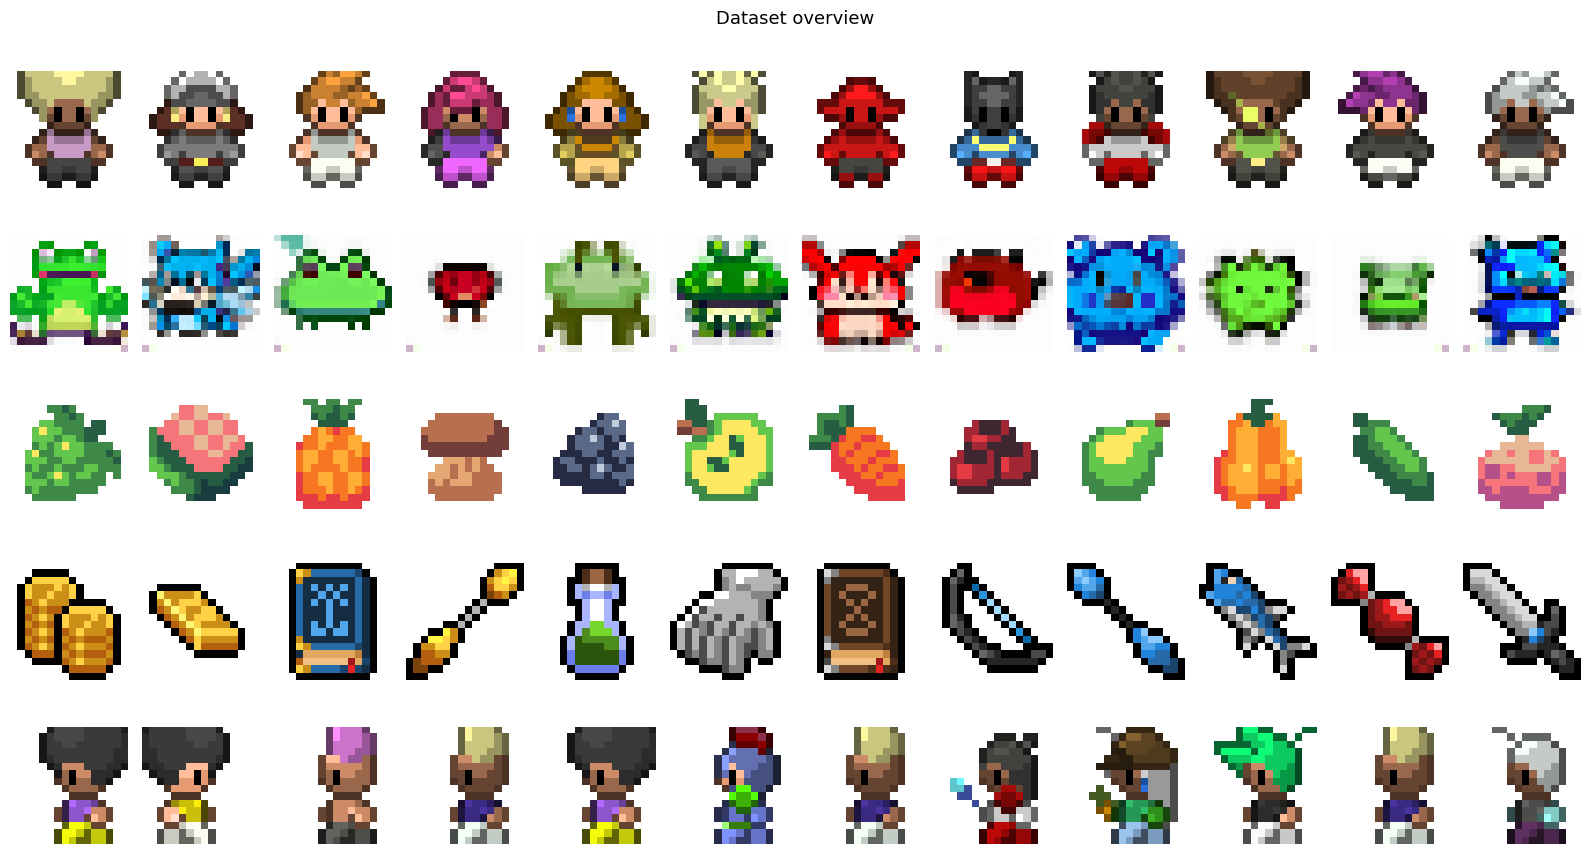

In [6]:
# just showing 12 per class  - viusalization
fig, axes = plt.subplots(NUM_CLASSES, 12, figsize=(16, NUM_CLASSES * 1.8))
fig.suptitle('Dataset overview', fontsize=13)

for cat in range(NUM_CLASSES):
    chosen = np.random.choice(np.where(label_indices == cat)[0], 12, replace=False)
    for col, idx in enumerate(chosen):
        axes[cat,col].imshow(sprites[idx])
        axes[cat,col].axis('off')
    # label on the left side
    
    axes[cat,0].set_ylabel(CLASS_NAMES[cat],fontsize=8,rotation=0,labelpad=110,va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/dataset_overview.png',dpi=120,bbox_inches='tight')
plt.show()

## 3. Preprocessing & DataLoader

In [7]:
IMG_SIZE=16
BATCH_SIZE=256
NUM_WORKERS=2

class SpriteDataset(Dataset):
    def __init__(self,sprites,label_indices):
        self.sprites=sprites
        self.labels= label_indices

    def __len__(self):
        return len(self.sprites)

    def __getitem__(self,idx):
        img=self.sprites[idx].astype(np.float32) / 127.5 - 1.0 # normalize to [-1, 1]
        img=torch.from_numpy(img).permute(2, 0, 1)
        return img,int(self.labels[idx])

full_dataset=SpriteDataset(sprites,label_indices)

n_val=int(0.1 * len(full_dataset)) ## 10% of the dataset used for validation
n_train= len(full_dataset) - n_val ## for 90% training

train_dataset,val_dataset=random_split(full_dataset,[n_train,n_val],generator=torch.Generator().manual_seed(SEED))

train_loader=DataLoader(train_dataset, batch_size=BATCH_SIZE,shuffle=True, num_workers=NUM_WORKERS,drop_last=True)
val_loader=DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=NUM_WORKERS)

print(f'train:{n_train},{len(train_loader)} batches')


print(f'val:{n_val}')

train:80460,314 batches
val:8940


## 4. Forward Diffusion Process

We implement **DDPM** - taken from(Ho et al., 2020). The forward process adds Gaussian noise over T timesteps:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

In [8]:
# forward diffusion process
# as t increasess, more noise is added and the image becomes pure gaussian noise at t=T(300)

T=300
betaStart=1e-4
betaEnd=0.02
# linear schedule: beta increases from betaStart to betaEnd over T steps
betas=torch.linspace(betaStart,betaEnd,T).to(DEVICE)
alphas=1.0-betas

alphaBars =torch.cumprod(alphas ,dim=0)

sqrt_ab=torch.sqrt(alphaBars) ## signal coef
sqrt_1mab =torch.sqrt(1.0 - alphaBars) ## noise coeeff

def q_sample(x0,t,noise=None):
    if noise is None:
            noise=torch.randn_like(x0)
    ab=sqrt_ab[t].view(-1,1,1,1)
    
    ab1m=sqrt_1mab[t].view(-1,1,1,1)
    return ab * x0 +  ab1m * noise, noise ## returns the noisey img and the noise added

print(f'T={T}, betas {betaStart} to {betaEnd}')


T=300, betas 0.0001 to 0.02


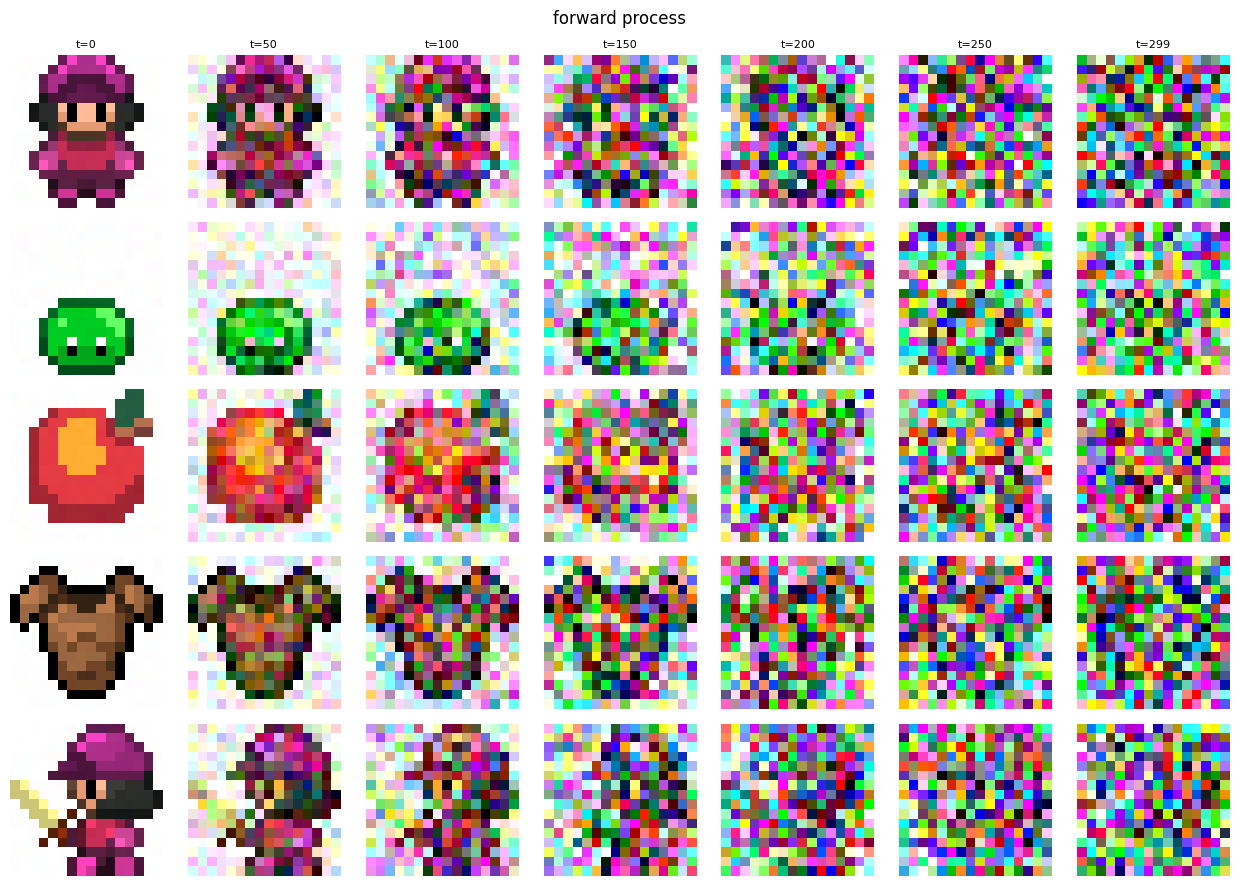

In [9]:
# visualize forward diffusion, one example per class
#each col is a timestep - shows how the img degrades when noise is being added 
steps_show = [0, 50, 100, 150, 200, 250, 299]  

fig,axes = plt.subplots(NUM_CLASSES, len(steps_show),figsize=(len(steps_show)*1.8, NUM_CLASSES*1.8))
fig.suptitle('forward process', fontsize=12)

for cat in range(NUM_CLASSES):
    idx =np.where(label_indices == cat)[0][0]
    raw_img = full_dataset[idx][0].unsqueeze(0).to(DEVICE)

    for col, t_val in enumerate(steps_show):
        #q smaple : to jump directly to the t val without iterating 
        noisy,_= q_sample(raw_img,torch.tensor([t_val],device=DEVICE))
        # denoising for display
        
        img_show=noisy[0].permute(1,2,0).cpu().clamp(-1,1).numpy()*0.5+0.5
        
        axes[cat, col].imshow(img_show)
        axes[cat, col].axis('off')
        
        if cat == 0:
            axes[cat, col].set_title(f't={t_val}',fontsize=8)

    
    axes[cat, 0].set_ylabel(CLASS_NAMES[cat],fontsize=7,rotation=0, labelpad=90, va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/forward_process.png', dpi=120)
plt.show()
##by t=299 all class structure is lost — the model must learn to how to reverse this

## 5. Model — Class-Conditional Tiny U-Net

Each ResBlock receives a conditioning vector = **timestep embedding + class embedding**.
This lets the model learn a separate generation distribution per sprite category.

Sinusoidal timestep embedding
Encodes scalar timestep t into a fixed-size vector so the model knows how much noise is present at each denoising step.

In [10]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim=dim

    def forward(self, t):
        # splitting the embedding into sin and cos halves
        half=self.dim//2
        freqs=torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half-1))
        #each timestep gets scaled by every frequency
        args=t[:, None].float()* freqs[None]
        #concat sin and cos of shape (batch,dim)
        return torch.cat([args.sin(),  args.cos()],dim=-1)

In [11]:
## Residual Block 
class ResBlock(nn.Module):
    # residual block with conditioning injection
    # used at every level of the u-net encoder and decoder
    def __init__(self,in_ch,out_ch,cond_dim):
        super().__init__()
        self.conv1=nn.Conv2d(in_ch, out_ch,3,padding=1)
        
        self.conv2=nn.Conv2d(out_ch, out_ch,3,padding=1)
        #groupnorm is more stable than batchnorm at small batch sizes
        self.norm1=nn.GroupNorm(8,out_ch)
        
        self.norm2=nn.GroupNorm(8,out_ch)
        self.cond_fc=nn.Linear(cond_dim,out_ch)
        # skip connection- 1x1 conv if channel dims differ, identity otherwise
        self.skip=nn.Conv2d(in_ch,out_ch,1) if in_ch != out_ch else nn.Identity()
        self.act=nn.SiLU()

    def forward(self,x,cond):
        h=self.act(self.norm1(self.conv1(x)))
        #inject conditioning: project to out_ch,then broadcast spatially
        #[:,:,None,None] expands (batch,ch) into (batch, ch,1,1) so it adds to every pixel
        h=h+self.cond_fc(self.act(cond))[:,:,None,None] 
        h=self.act(self.norm2(self.conv2(h)))
        #the residual connection added stabilized the training and helos the gradients flow  
        return h+self.skip(x)

In [12]:
class Downsample(nn.Module):
# learnable downsampling byy strided conv (stride=2)---> halves spatial dims
# preferred over MaxPool bcs it lets the model learn what to keep
    def __init__(self,ch):
        super().__init__()
        # kernel =4, stride=2, pad=1 --> HxW --> H/2 x W/2
        self.c =nn.Conv2d(ch,ch,4,2,1)

    def forward(self,x):
        return self.c(x)



class Upsample(nn.Module):
# learnable upsampling byy transposed conv (stride=2) ---> doubles spatial dims
# mirrors downsample so encoder and decoder levels match for skip connections

    def __init__(self,ch):
        super().__init__()
        # kernel =4, stride=2, pad=1 --> HxW --> 2H x 2W
        self.c=nn.ConvTranspose2d(ch,ch,4,2,1) 

    def forward(self,x):
        return self.c(x)

In [13]:
class ConditionalUNet(nn.Module):
 # u-net denoising backbone conditioned on both timestep and class label
 #architecture: encoder 16x16-->8x8 --> 4x4, bottleneck 4x4, decoder 4x4 --> 8x8 -->16x16
   
    def __init__(self, in_ch=3, base_ch=64, time_dim=128, num_classes=5):
        super().__init__()
        # timestep embedding= sinusoidal
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim*2), nn.SiLU(),
            nn.Linear(time_dim*2, time_dim),
        )
         # class embedding -learned vector per class

        self.class_emb = nn.Embedding(num_classes, time_dim)

        # encoder reduces spatial dims, increases channels
        self.enc1 = ResBlock(in_ch,base_ch,time_dim) #16x16, 64ch
        
        self.down1 = Downsample(base_ch)
        self.enc2 = ResBlock(base_ch,base_ch*2,time_dim)#8x8,  128ch
        
        self.down2 = Downsample(base_ch*2)

        # bottleneck  two ResBlocks at lowest resolution for global context
        self.mid1 = ResBlock(base_ch*2, base_ch*4,time_dim)
        self.mid2 = ResBlock(base_ch*4,base_ch*4, time_dim)

        # decoder upsamples and concatenates skip connections from encoder
        ##input channels = upsampled channels + skip channels
        self.up2 = Upsample(base_ch*4)
        self.dec2 = ResBlock(base_ch*6,base_ch*2, time_dim)
        self.up1 = Upsample(base_ch*2)
        self.dec1 = ResBlock(base_ch*3, base_ch,time_dim)
        # projects back to image channels
        self.out = nn.Sequential(nn.GroupNorm(8, base_ch),nn.SiLU(),nn.Conv2d(base_ch,in_ch,1))

    def forward(self, x, t, c):
        ## combine time and class into one conditioning vector
        cond = self.time_mlp(t) + self.class_emb(c)
        
        # encoder path
        e1 = self.enc1(x, cond)
        e2 = self.enc2(self.down1(e1), cond)
        #bottlenaeck
        b = self.mid1(self.down2(e2), cond)
        b = self.mid2(b, cond)
        #decoder path  concatenate upsampled features with encoder skip
        d2 = self.dec2(torch.cat([self.up2(b), e2], 1), cond)
        
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1), cond)
        
        return self.out(d1)


In [14]:
model= ConditionalUNet(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params/1e6:.2f}M')

# quick check for output  - must match input shape 
x = torch.randn(4, 3, 16, 16).to(DEVICE)
t = torch.randint(0, T, (4,)).to(DEVICE)
c = torch.randint(0, NUM_CLASSES, (4,)).to(DEVICE)
assert model(x, t, c).shape == (4, 3, 16, 16)
print('shape ok')

Parameters: 4.99M
shape ok


## 6. Training

In [15]:
EPOCHS=100
LR=2e-4
SAVE_DIR=Path('/kaggle/working/checkpoints' )


SAVE_DIR.mkdir(exist_ok=True)

#AdamW:adam with decoupled weight decay, better generalization than Adam
optimizer=torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
#cosine annealing: smoothly decays LR to 0 over training,avoids sharp LR drops that can destabilize diffusion training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def p_loss(model, x0, t, c):
    noisy, noise = q_sample(x0, t)
    return F.mse_loss(model(noisy, t, c), noise)


In [16]:
train_losses, val_losses = [], []

print(f'Training {EPOCHS} epochs , LR={LR} , Batch={BATCH_SIZE} , T={T}')

Training 100 epochs , LR=0.0002 , Batch=256 , T=300


In [17]:
for epoch in range(1, EPOCHS+1):
    model.train()
    eloss=0.0
    for imgs,lbls in tqdm(train_loader,desc=f'Epoch {epoch}/{EPOCHS}',leave=False):
        imgs, lbls =imgs.to(DEVICE),lbls.to(DEVICE) 
        # sample a random timestep for each image in the batch
        t = torch.randint(0, T, (imgs.size(0), ),device=DEVICE)
        
        optimizer.zero_grad()
        loss = p_loss(model,imgs,t,lbls)
        
        loss.backward()
        #prevents exploding gradients, found common in diffusion training
        nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        eloss+= loss.item()
    
    train_losses.append(eloss / len(train_loader))

    model.eval()
    vloss = 0.0
    
    with torch.no_grad():
        for imgs,lbls in val_loader:
            imgs,lbls =imgs.to(DEVICE),lbls.to(DEVICE)
            t = torch.randint(0,T,(imgs.size(0),),device=DEVICE)
            vloss += p_loss(model, imgs, t, lbls).item()
    val_losses.append(vloss/len(val_loader))
    scheduler.step()

    if epoch%10 == 0:
        print(f'epoch {epoch} - train {train_losses[-1]:.4f} val{val_losses[-1]:.4f}')

print('done')

epoch 10 - train 0.0535 val0.0518


epoch 20 - train 0.0361 val0.0378


epoch 30 - train 0.0293 val0.0317


epoch 40 - train 0.0246 val0.0258


epoch 50 - train 0.0215 val0.0225


epoch 60 - train 0.0187 val0.0185


epoch 70 - train 0.0158 val0.0155


epoch 80 - train 0.0135 val0.0133


epoch 90 - train 0.0121 val0.0125


epoch 100 - train 0.0117 val0.0116
done


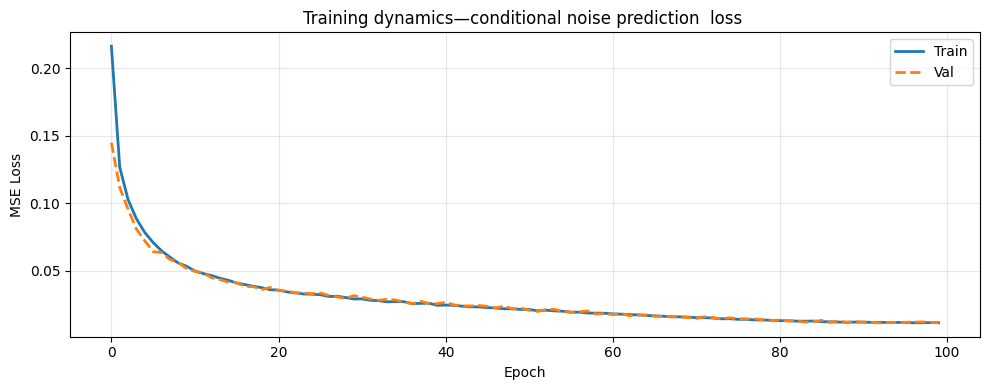

In [18]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(train_losses, label='Train', linewidth=2)
ax.plot(val_losses,label='Val',linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training dynamics—conditional noise prediction  loss ')
ax.legend() 
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## 7. Conditional Sampling

Starting from just noise, we iteratively denoise using the class label as a condition:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\hat{\epsilon}_\theta(x_t, t, c)\right) + \sigma_t z$$

In [19]:
@torch.no_grad()
def p_sample(model, x, t_val, class_label):
    B= x.size(0)
    t_t= torch.full((B,),t_val, device=DEVICE,dtype=torch.long)
    c_t= torch.full((B,),class_label,device=DEVICE, dtype=torch.long)
     # predicting the noise that was added at this timestep
    pred= model(x, t_t,c_t)  
    #computing the posterior mean using the predicted noise ,coef scales how much of the predicted noise to subtract
    
    beta_t= betas[t_val] 
    coef= beta_t / torch.sqrt(1 - alphaBars[t_val])
    mean= (1/torch.sqrt(alphas[t_val])) * (x-coef* pred)
    
    if t_val == 0: 
        return mean
     # add noise scaled by sqrt(beta_t)  (Markov chain addition )
    return mean + torch.sqrt(beta_t)*torch.randn_like(x)

@torch.no_grad()
def sample_class(model, class_label, n_samples=16):
    model.eval()
   #from pure gaussian noise x_T and denoise down to x_0
    x = torch.randn(n_samples, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    for t_val in tqdm(reversed(range(T)), total=T, leave=False):
        x=p_sample(model, x , t_val,class_label) 
        
    return x ##final generated image


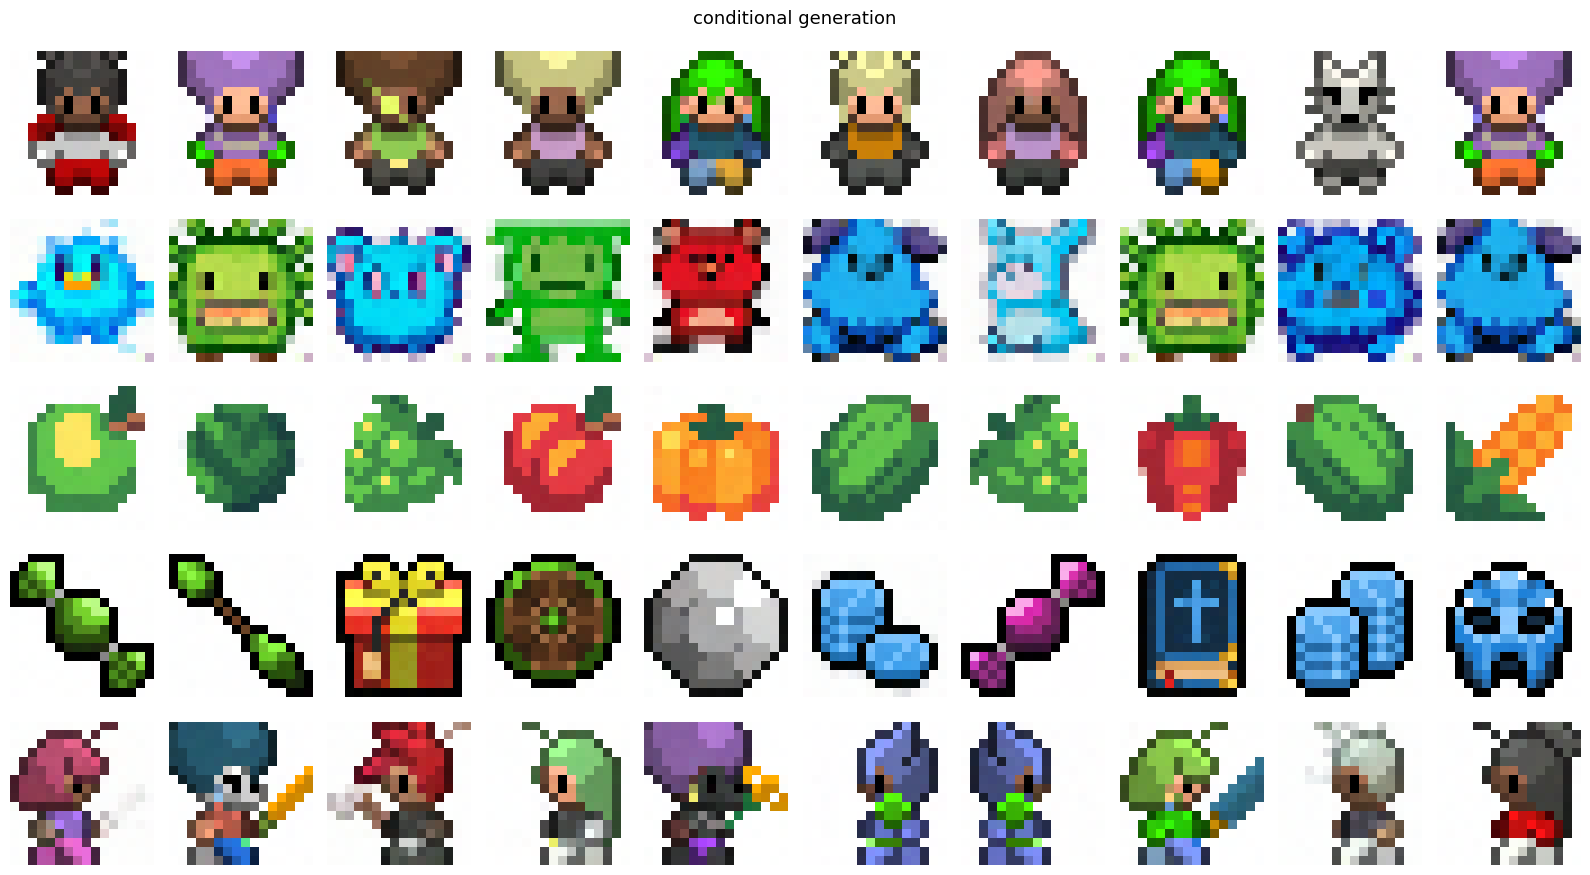

In [20]:
# generate 10 samples per class
N_SHOW=10
all_generated={}

fig,axes = plt.subplots(NUM_CLASSES,N_SHOW,figsize=(N_SHOW*1.6,NUM_CLASSES*1.8))
fig.suptitle('conditional generation',fontsize=13)

for cat in range(NUM_CLASSES):
    gen = sample_class(model,class_label=cat,n_samples=N_SHOW)
    all_generated[cat] = gen
    for col in range(N_SHOW):
        img = (gen[col].clamp(-1,1)*0.5+0.5).permute(1, 2, 0).cpu()
        axes[cat, col].imshow(img)
        axes[cat, col].axis('off')
    axes[cat, 0].set_ylabel(CLASS_NAMES[cat], fontsize=8,rotation=0,labelpad=100,va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/conditional_samples.png', dpi=120)
plt.show()

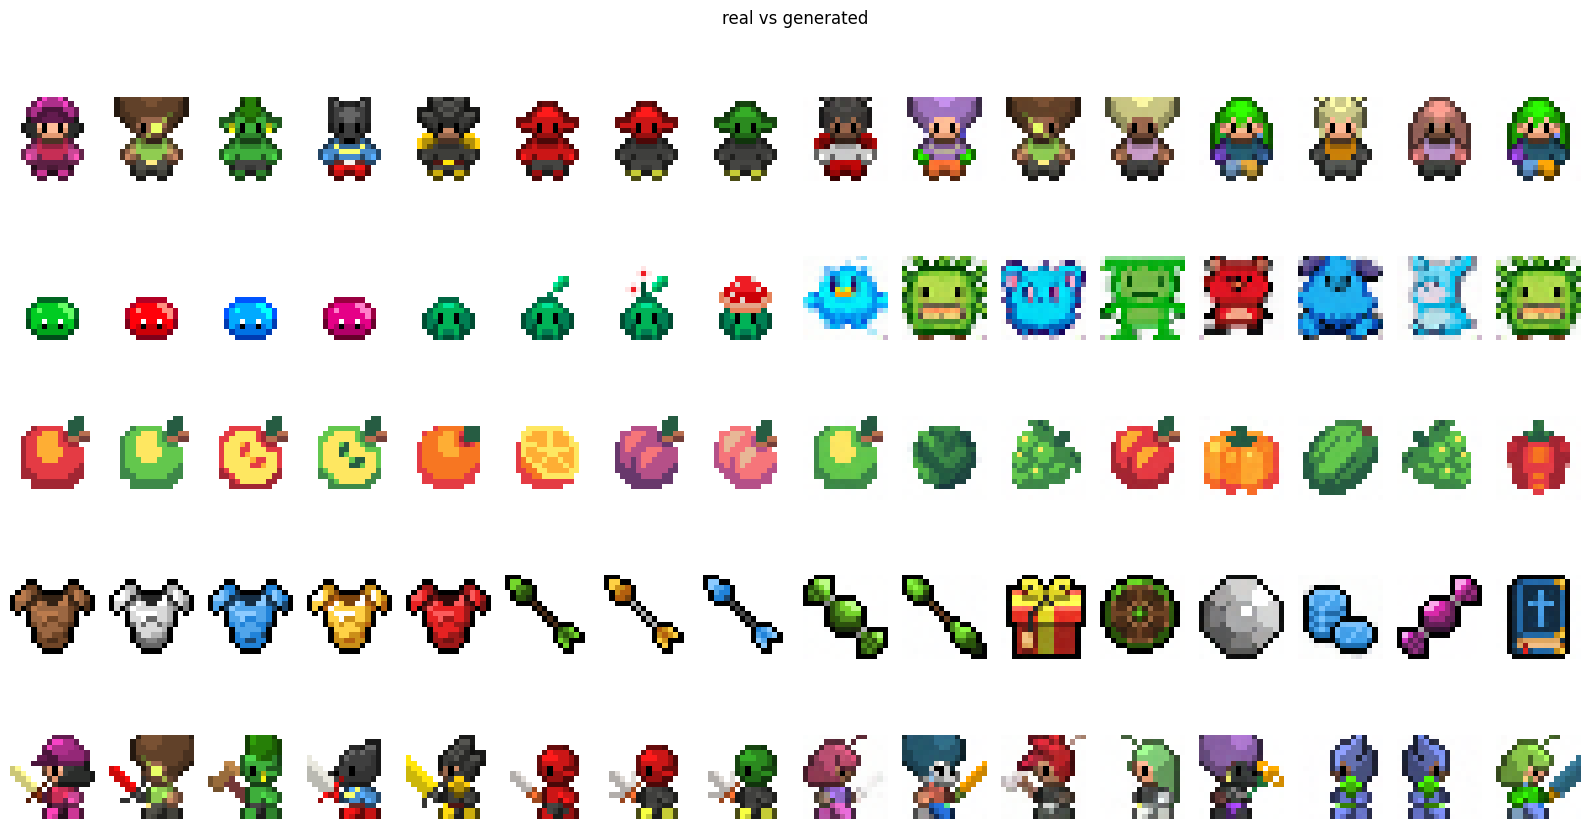

In [21]:
# Real vs Generated side-by-side
fig, axes = plt.subplots(NUM_CLASSES, 16, figsize=(16, NUM_CLASSES*1.8))
fig.suptitle('real vs generated', fontsize=12)

for cat in range(NUM_CLASSES):
    real_idx = np.where(label_indices == cat)[0][:8]
    
    
    for col, idx in enumerate(real_idx):
        axes[cat, col].imshow(sprites[idx])
        axes[cat, col].axis('off')
    axes[cat, 0].set_ylabel(CLASS_NAMES[cat], fontsize=7,rotation=0, labelpad=100, va='center')
    
    for col, img_t in enumerate(all_generated[cat][:8]):
        img = (img_t.clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu()
        axes[cat,col+8].imshow(img)
        axes[cat,col+8].axis('off')

plt.tight_layout() 
plt.savefig('/kaggle/working/real_vs_generated.png',dpi=120)  
plt.show()

## 8. Evaluation — FID per Category

We compute FID separately for each class to measure which categories the model learned best.
FID (Frechet Inception Distance) measures the distance between real and generated image distributions using InceptionV3 features where lower means better

In [22]:
from cleanfid import fid as cleanfid

N_FID=1000
fid_scores={}

for cat in range(NUM_CLASSES):
    real_dir = Path(f'/kaggle/working/fid_real_{cat}')
    
    
    real_dir.mkdir(exist_ok=True)
    gen_dir = Path(f'/kaggle/working/fid_gen_{cat}')
    gen_dir.mkdir(exist_ok=True)

    ##saving real images for each class 
    for i, idx in enumerate(np.where(label_indices == cat)[0][:N_FID]):
        Image.fromarray(sprites[idx]).save(real_dir / f'{i}.png')

    #generating in batches of 64 
    print(f'generating {N_FID} samples for class {cat}')
    gen_all = []
    for start in tqdm(range(0,N_FID,64)):
        n = min(64,N_FID-start)
        gen_all.append(sample_class(model, cat, n_samples=n))
    gen_all = torch.cat(gen_all)

    #denormalizing from [-1,1] to [0,255] uint8 before saving
    for i,img_t in enumerate(gen_all):
        img_np =(img_t.clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu().numpy()
        Image.fromarray((img_np*255).astype(np.uint8)).save(gen_dir/f'{i}.png')

    score = cleanfid.compute_fid(str(real_dir), str(gen_dir))
    fid_scores[cat] = score
    print(f'  class {cat} ({CLASS_NAMES[cat]}): {score:.2f}')

print('fid per class: ')
for cat, s in fid_scores.items():
    print(f'{cat} -{CLASS_NAMES[cat]}: {s:.2f}')
print(f'mean FID:{np.mean(list(fid_scores.values())):.2f}')

generating 1000 samples for class 0


100%|██████████| 16/16 [00:40<00:00,  2.51s/it]   
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


compute FID between two folders
Found 1000 images in the folder /kaggle/working/fid_real_0


FID fid_real_0 :   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
FID fid_real_0 : 100%|██████████| 32/32 [00:06<00:00,  4.83it/s]


Found 1000 images in the folder /kaggle/working/fid_gen_0


...

compute FID between two folders
Found 1000 images in the folder /kaggle/working/fid_real_4


FID fid_real_4 : 100%|██████████| 32/32 [00:06<00:00,  4.78it/s]


Found 1000 images in the folder /kaggle/working/fid_gen_4


FID fid_gen_4 : 100%|██████████| 32/32 [00:06<00:00,  5.10it/s]


  class 4 (Characters (with weapon)): 23.08
fid per class: 
0 -Characters (no weapon): 18.03
1 -Fruits & objects: 40.96
2 -Large fruits: 29.34
3 -Armors & arrows: 31.80
4 -Characters (with weapon): 23.08
mean FID:28.64


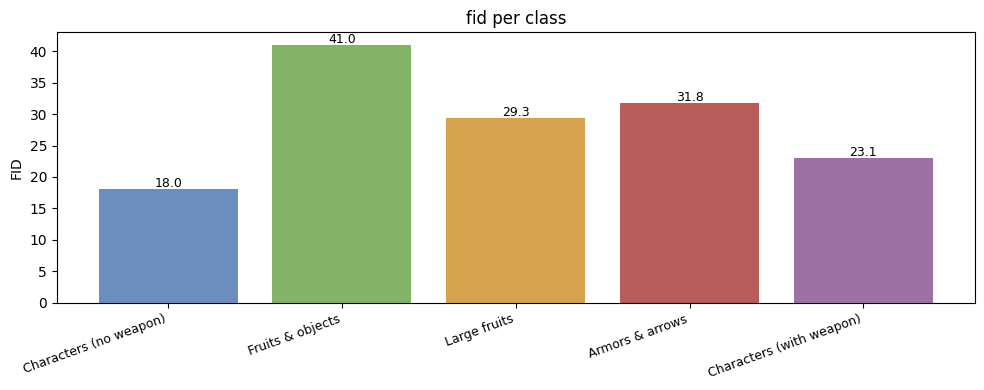

In [23]:
fig,ax=plt.subplots(figsize=(10, 4))
colors=['#6c8ebf','#82b366','#d6a24d','#b85c5c','#9b72a1']
bars = ax.bar(range(NUM_CLASSES),[fid_scores[i] for i in range(NUM_CLASSES)],color=colors)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=20,ha='right',fontsize=9)
ax.set_ylabel('FID')
ax.set_title('fid per class')


for bar, val in zip(bars, fid_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2,bar.get_height()+ 0.3,f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/fid_per_class.png')
plt.show()

## 9. Ablation Studies

Three ablations:
1. Sampling steps — does fewer steps hurt quality
2. Model size — smallest usable model
3. Conditional vs Unconditional — does class conditioning help

### Ablation 1:Sampling steps 
how many reverse diffusion steps do we actually need

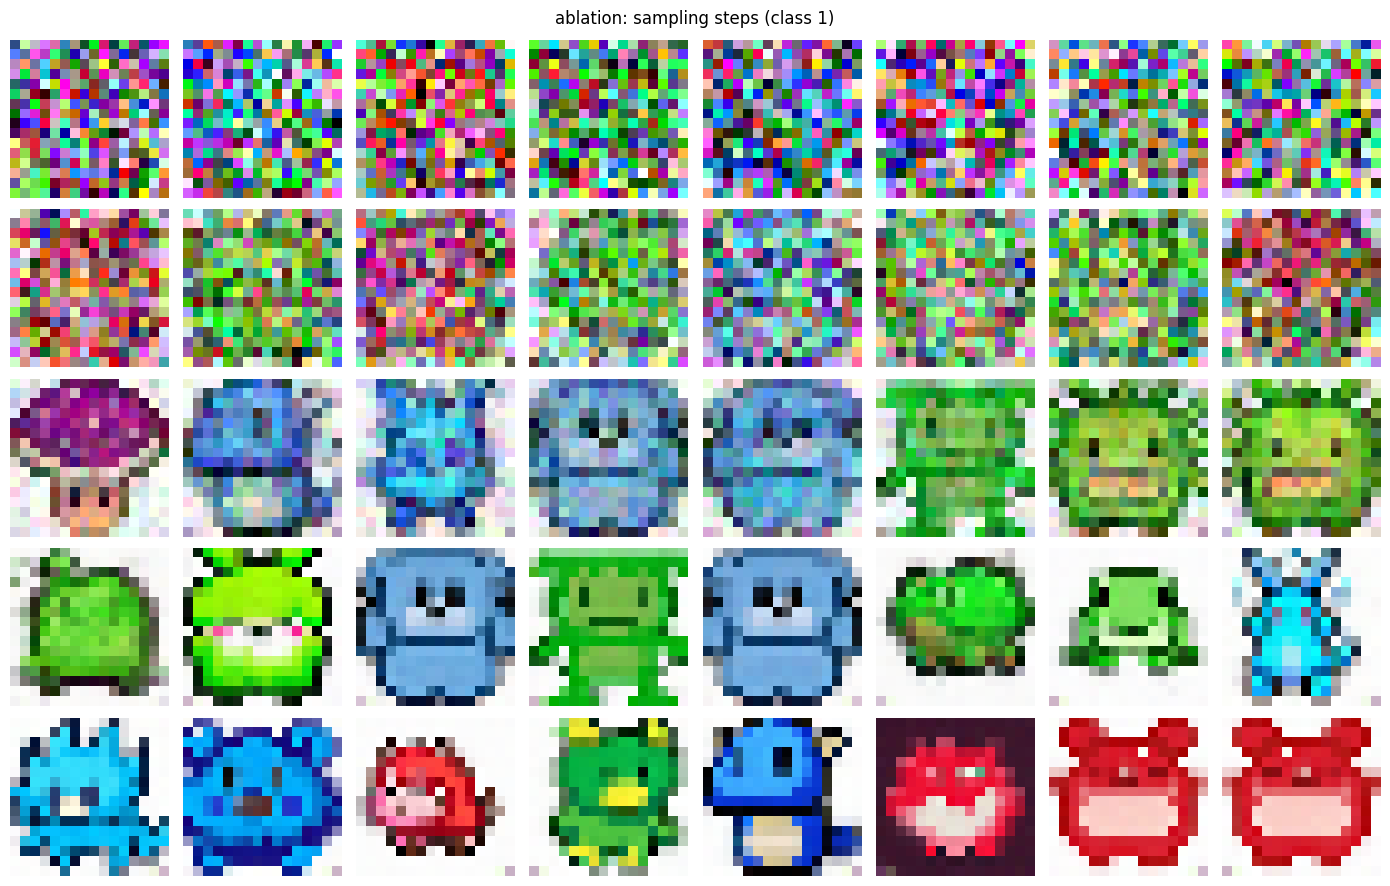

In [24]:
## Full 300 is sloww. fewer steps = faster but lower quality
@torch.no_grad()
def sample_with_steps(model, class_label, n_steps, n_samples=8):
    model.eval()
    x = torch.randn(n_samples, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    # subsample timesteps uniformly from T-1 down to 0
    steps = torch.linspace(T-1,0, n_steps).long().tolist()
    for t_val in steps:
        x = p_sample(model, x, t_val, class_label)
    
    return x

ablation_steps = [25,50,100,200,300]
TARGET_CLASS = 1  #fruits, most visually distinct

fig, axes = plt.subplots(len(ablation_steps), 8,figsize=(14, len(ablation_steps)*1.8))
fig.suptitle(f'ablation: sampling steps (class {TARGET_CLASS})', fontsize=12)

for row, n_steps in enumerate(ablation_steps):
    gen = sample_with_steps(model, TARGET_CLASS, n_steps)
    for col in range(8):
        axes[row, col].imshow((gen[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu())
        axes[row, col].axis('off')
    
    axes[row, 0].set_ylabel(f'{n_steps} steps',fontsize=9,rotation=0, labelpad=55, va='center')


## visualize-
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_steps.png', dpi=120)
plt.show()
# expected: quality degrades below ~100 steps as too many denoising steps are skipped

In [25]:
##notes about the output
# results: quality threshold is around 100 steps
# 25-50 steps: too few, noise dominates
# 100 steps: coherent shapes emerge — good speed/quality tradeoff
# 200-300 steps: marginal improvement, diminishing returns

### Ablation 2: Model Size 
does a larger model help, and is 64 channels the right choice?

In [26]:
# we compare base channel counts {32, 48, 64, 96} by training each briefly
# and measuring validation loss as a proxy for model capacity vs compute

#5 epcochs just so each model gets the same training - for fast evaluation results 
def quick_eval(base_ch, quick_epochs=5):
    m =ConditionalUNet(base_ch=base_ch, num_classes=NUM_CLASSES).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(),lr=LR)
    m.train()
    
    for _ in range(quick_epochs):
        for imgs,lbls in train_loader:
            imgs,lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)
            opt.zero_grad()
            p_loss(m, imgs, t, lbls).backward()
            opt.step()
    
    m.eval()
    vl = 0.0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)
            vl += p_loss(m, imgs, t, lbls).item()
    
    return vl/len(val_loader), sum(p.numel() for p in m.parameters())

size_configs = [32,48,64,96]
size_results = {}

for ch in size_configs:
    if ch == 64:
        # reuse already-trained model results instead of retraining from scratch
        size_results[ch] = (val_losses[-1], total_params)
    else:
        size_results[ch] = quick_eval(ch)
    
    print(f'base_ch={ch}{size_results[ch][1]/1e6:.2f}M params val_loss={size_results[ch][0]:.4f}')


base_ch=321.33M params val_loss=0.1183
base_ch=482.86M params val_loss=0.0934
base_ch=644.99M params val_loss=0.0116
base_ch=9611.05M params val_loss=0.0606


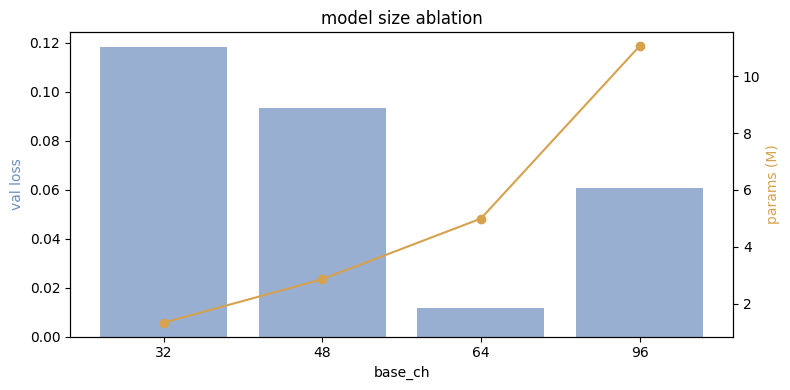

In [27]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
chs = list(size_results.keys())
losses= [size_results[c][0] for c in chs]
params= [size_results[c][1]/1e6 for c in chs]
ax1.bar([str(c) for c in chs],losses, color='#6c8ebf',alpha=0.7)
ax2.plot([str(c) for c in chs],params, 'o-', color='#d6a24d')
ax1.set_xlabel('base_ch')
ax1.set_ylabel('val loss', color='#6c8ebf')
ax2.set_ylabel('params (M)', color='#d6a24d')
ax1.set_title('model size ablation')

plt.tight_layout()
plt.savefig('/kaggle/working/ablation_model_size.png', dpi=120)
plt.show()

In [ ]:
##notes about the output chart
#base_ch=64 result uses 100-epoch training, others use 5 epochss
#the val loss gap reflects both capacity and training time differences
#among 5-epoch models: 32&48 shows clear improvement, 96 likely needs more epochs to converge

### Ablation 3: conditional vs  unconditional 

In [32]:

class UnconditionalUNet(ConditionalUNet):
    # same arch, just drops the class embedding
   # conditioning vector is timestep only → model has no class information at sampling time
    def forward(self, x, t, c=None):
        #baseline to compare against conditional and CFG models
        cond = self.time_mlp(t)
        e1= self.enc1(x,cond)
        e2= self.enc2(self.down1(e1),cond)
        b= self.mid1(self.down2(e2), cond)
        b= self.mid2(b,cond)
        d2= self.dec2(torch.cat([self.up2(b),e2],1),cond)
        d1= self.dec1(torch.cat([self.up1(d2),e1],1),cond)
        
        return self.out(d1)


In [33]:
#train unconditional model under identical conditions to the conditional model
#same optimizer, lr, scheduler, and epochs to get a  fair comparison
uncond = UnconditionalUNet(num_classes=NUM_CLASSES).to(DEVICE)
opt_u = torch.optim.AdamW(uncond.parameters(), lr=LR, weight_decay=1e-4)
scheduler_u = torch.optim.lr_scheduler.CosineAnnealingLR(opt_u, T_max=EPOCHS)

print(f'training unconditional model for {EPOCHS} epochs')
for epoch in range(EPOCHS):
    uncond.train()
    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE)
        t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)
        opt_u.zero_grad()
        noisy, noise = q_sample(imgs, t)
        F.mse_loss(uncond(noisy, t), noise).backward()
        opt_u.step()
    scheduler_u.step()
    if epoch % 10 == 0:
        print(f'epoch {epoch} done')


training unconditional model for 100 epochs
epoch 0 done
epoch 10 done
epoch 20 done
epoch 30 done
epoch 40 done
epoch 50 done
epoch 60 done
epoch 70 done
epoch 80 done
epoch 90 done


In [59]:
# Unconditional train loss (post-hoc, one pass over training set)
uncond.eval()
tloss_u = 0.0
with torch.no_grad():
    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE)
        t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)
        noisy, noise = q_sample(imgs, t)
        pred = uncond(noisy, t)
        tloss_u += F.mse_loss(pred, noise).item()

uncond_train_loss = tloss_u / len(train_loader)

print(f'Unconditional train loss: {uncond_train_loss:.4f}')

print(f'Unconditional val loss:   {uncond_val_loss:.4f}')

Unconditional train loss: 0.0127
Unconditional val loss:   0.0128


In [51]:
##get validation loss 
uncond.eval()
vloss_u = 0.0
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE)
        t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)
        noisy, noise = q_sample(imgs, t)
        pred = uncond(noisy, t)
        vloss_u += F.mse_loss(pred, noise).item()

uncond_val_loss = vloss_u / len(val_loader)
print(f'Unconditional val loss: {uncond_val_loss:.4f}')
print(f'Conditional val loss:   {val_losses[-1]:.4f}')

Unconditional val loss: 0.0128
Conditional val loss:   0.0116


In [34]:
# generatibg samples from both models for the same class
cond_gen = sample_class(model, TARGET_CLASS, n_samples=10)
uncond_gen = sample_class(uncond, TARGET_CLASS, n_samples=10)

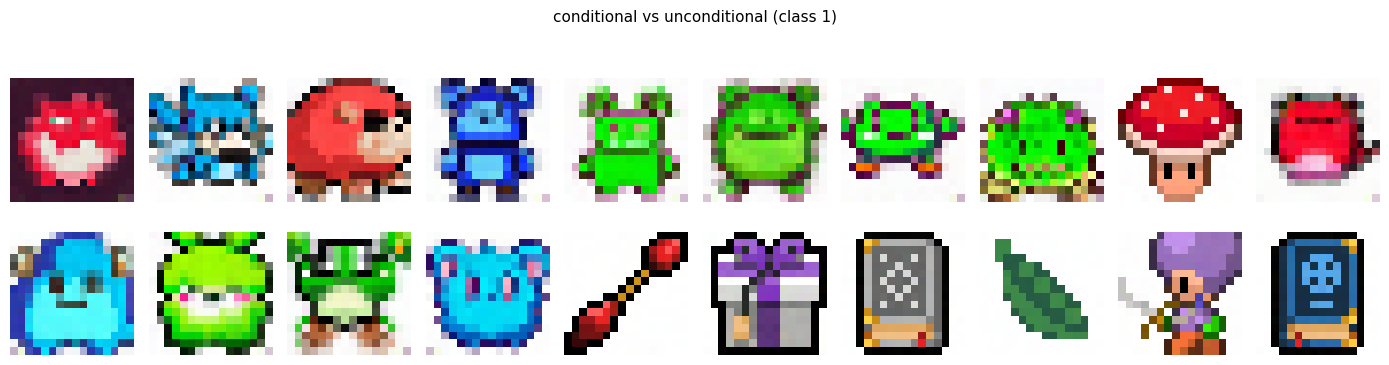

In [35]:

fig, axes = plt.subplots(2,10,figsize=(14, 4))
fig.suptitle(f'conditional vs unconditional (class {TARGET_CLASS})', fontsize=11)
for col in range(10):
    axes[0,col].imshow((cond_gen[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu())
    axes[0,col].axis('off')
    axes[1,col].imshow((uncond_gen[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu())
    axes[1,col].axis('off')
axes[0,0].set_ylabel('conditional',fontsize=9, rotation=0,labelpad=70, va='center')
axes[1,0].set_ylabel('unconditional',fontsize=9, rotation=0,labelpad=80, va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/ablation_conditional.png', dpi=120)
plt.show()

### CFG - For comparison with conditional and unconditional

Part 1 had - separately trained
Train conditional model (100 epochs)
Train unconditional model (100 epochs)

**CFG does:**

Train one model only (100 epochs) where during each batch, 90% of the time it sees the real label (cond), 10%  of the time the label is replaced with a null token (uncond) and compare with 80% real 20% null



--- training CFG with P_UNCOND=0.1 ---


  epoch 10 - loss 0.0532


  epoch 20 - loss 0.0369


  epoch 30 - loss 0.0301


  epoch 40 - loss 0.0256


...

  epoch 60 - loss 0.0190


  epoch 70 - loss 0.0157


  epoch 80 - loss 0.0136


  epoch 90 - loss 0.0123


  epoch 100 - loss 0.0119

done. both models trained.


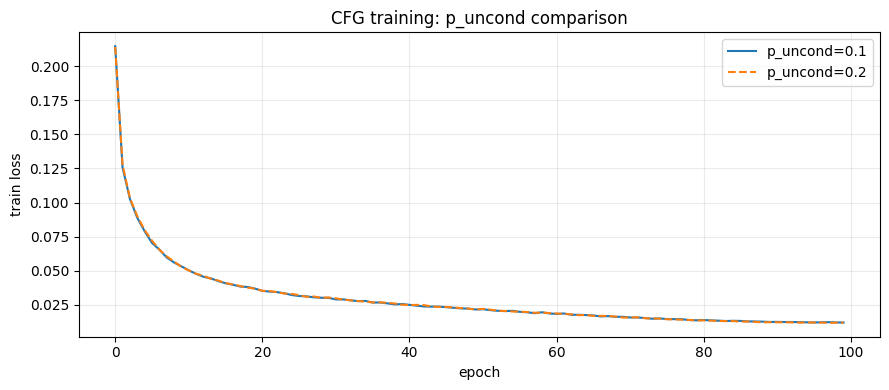

In [36]:
# train CFG model twice - once with p=0.1, once with p=0.2
CFG_EPOCHS=100
NULL_CLASS=NUM_CLASSES #index 5 acts as the "no class" null token

cfg_results = {}
#p_uncond controls how often the class label is dropped during training
for P_UNCOND in [0.1, 0.2]:
    print(f'--- training CFG with P_UNCOND={P_UNCOND} ---')
    
    cfg_model = ConditionalUNet(num_classes=NUM_CLASSES + 1).to(DEVICE)
    opt_cfg = torch.optim.AdamW(cfg_model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler_cfg = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cfg, T_max=CFG_EPOCHS)
    cfg_train_losses = []

    for epoch in range(1, CFG_EPOCHS + 1):
        cfg_model.train()
        eloss = 0.0
        for imgs, lbls in tqdm(train_loader, desc=f'CFG p={P_UNCOND} epoch {epoch}/{CFG_EPOCHS}', leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)
             # randomly replace puncond fraction of labels with null token
            # forcing the model to learn unconditional denoising alongside conditional
            
            mask = torch.rand(imgs.size(0), device=DEVICE) < P_UNCOND
            lbls_cfg = lbls.clone()
            lbls_cfg[mask] = NULL_CLASS
            
            noisy, noise = q_sample(imgs, t)
            opt_cfg.zero_grad()
            loss = F.mse_loss(cfg_model(noisy, t, lbls_cfg), noise)
            loss.backward()
            
            nn.utils.clip_grad_norm_(cfg_model.parameters(), 1.0)
            opt_cfg.step()
            eloss += loss.item()
        cfg_train_losses.append(eloss / len(train_loader))
        scheduler_cfg.step()
        if epoch % 10 == 0:
            print(f'  epoch {epoch} - loss {cfg_train_losses[-1]:.4f}')

    cfg_results[P_UNCOND] = {
        'model':cfg_model,
        'losses':cfg_train_losses
    }

print('\ndone. both models trained.')

# plot training curves side by side -- do the two dropout rates converge differently?
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cfg_results[0.1]['losses'], label='p_uncond=0.1')
ax.plot(cfg_results[0.2]['losses'], label='p_uncond=0.2', linestyle='--')
ax.set_xlabel('epoch')
ax.set_ylabel('train loss')
ax.set_title('CFG training: p_uncond comparison')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('/kaggle/working/cfg_puncond_comparison.png', dpi=120)
plt.show()
# our expectation: similar loss curves — p_uncond affects sampling quality, not training loss directly


In [37]:
@torch.no_grad()
def sample_cfg(model, class_label, guidance_scale=3.0, n_samples=8):
    model.eval()

    
    #starting from pure gaussian noise,, same as standard sampling
    x = torch.randn(n_samples, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    null = torch.full((n_samples,), NULL_CLASS, device=DEVICE, dtype=torch.long)
    c = torch.full((n_samples,), class_label, device=DEVICE, dtype=torch.long)

    for t_val in reversed(range(T)):
        t_t = torch.full((n_samples,), t_val, device=DEVICE, dtype=torch.long)
        
        #two forward passes per step: one conditional, one unconditional
        pred_cond = model(x, t_t, c)
        
        pred_uncond = model(x, t_t, null)
        # CFG blending: guidance_scale=1 --> standard conditional >1-> stronger class signal
        pred = pred_uncond + guidance_scale * (pred_cond - pred_uncond)

        # denoising step using blended prediction directly
        beta_t = betas[t_val]
        coef = beta_t / torch.sqrt(1 - alphaBars[t_val])
        mean = (1 / torch.sqrt(alphas[t_val])) * (x - coef * pred)
        if t_val == 0:
            x = mean
        else:
            x = mean + torch.sqrt(beta_t) * torch.randn_like(x)
    return x

###  Ablation 1: how does guidance scale affect quality vs diversity?

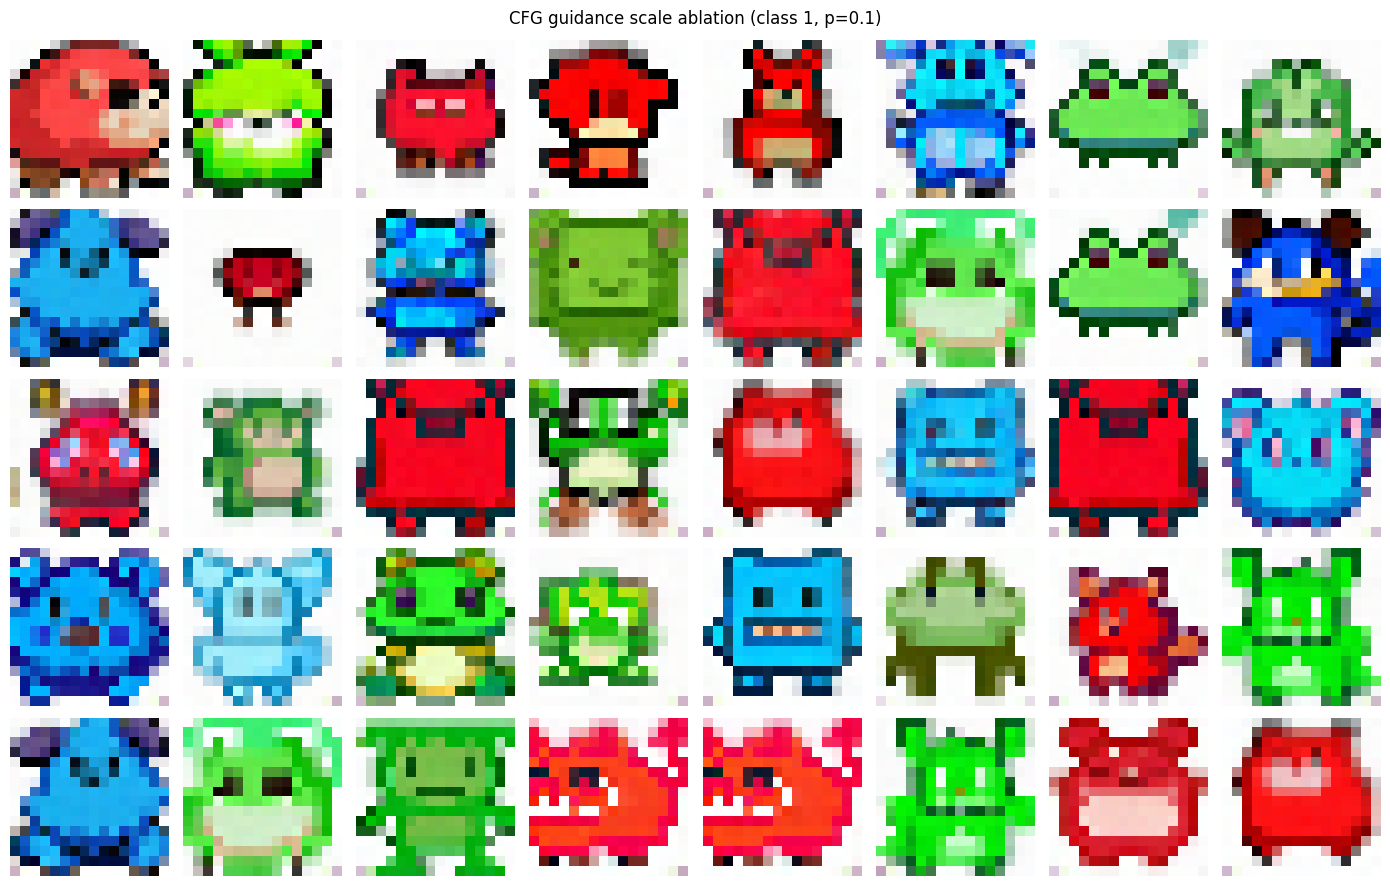

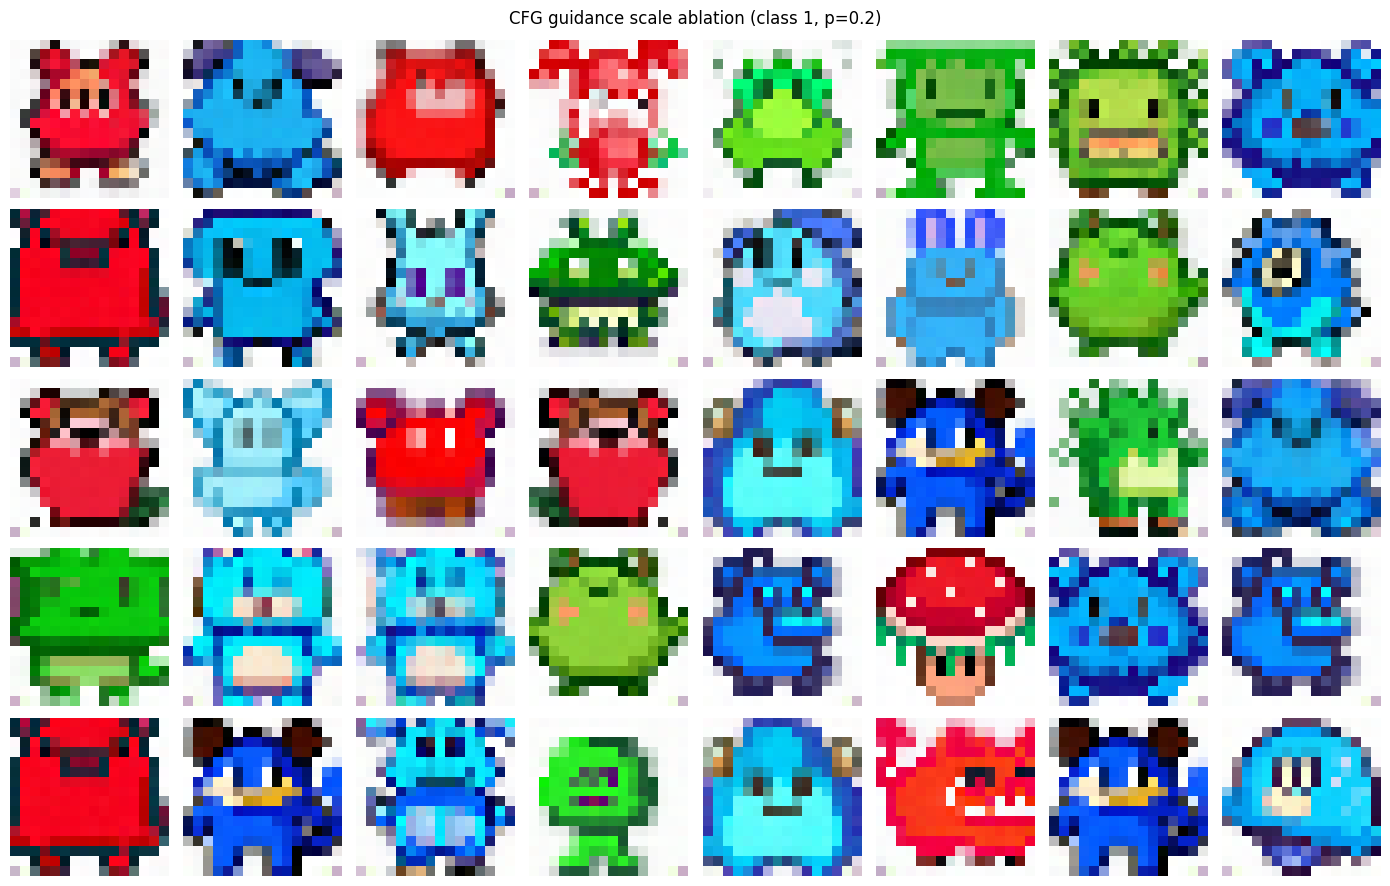

In [38]:
# tested on both p_uncond variants to see if dropout rate interacts with guidance scale
guidance_scales = [1.0, 1.5, 2.0, 3.0, 5.0]
TARGET_CLASS_CFG = 1  # fruits for comparison

for P_UNCOND in [0.1, 0.2]:
    cfg_model = cfg_results[P_UNCOND]['model']

    fig, axes = plt.subplots(len(guidance_scales), 8, figsize=(14, len(guidance_scales)*1.8))
    fig.suptitle(f'CFG guidance scale ablation (class {TARGET_CLASS_CFG}, p={P_UNCOND})', fontsize=12)

    for row, w in enumerate(guidance_scales):
        # higher w = stronger class push but less sample diversity
        # w=1.0 is equivalent to standard conditional sampling (no guidance amplification)
        gen = sample_cfg(cfg_model, TARGET_CLASS_CFG, guidance_scale=w)
        for col in range(8):
            img = (gen[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu()
            axes[row, col].imshow(img)
            
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(f'w={w}', fontsize=9, rotation=0, labelpad=45, va='center')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/cfg_guidance_ablation_p{P_UNCOND}.png', dpi=120)
    plt.show()
# expected: higher w degrades quality here since model capacity is too small for conditional/unconditional predictions to diverge meaningfully

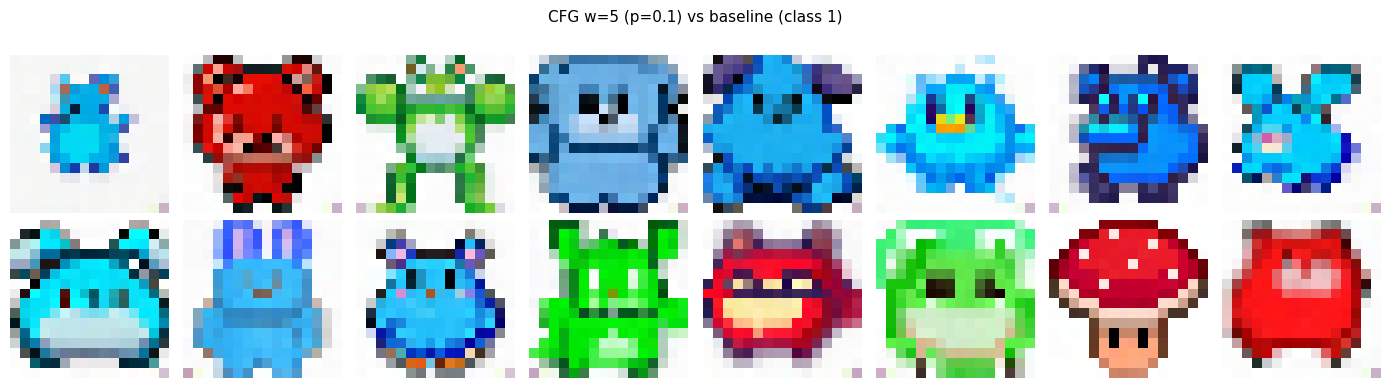

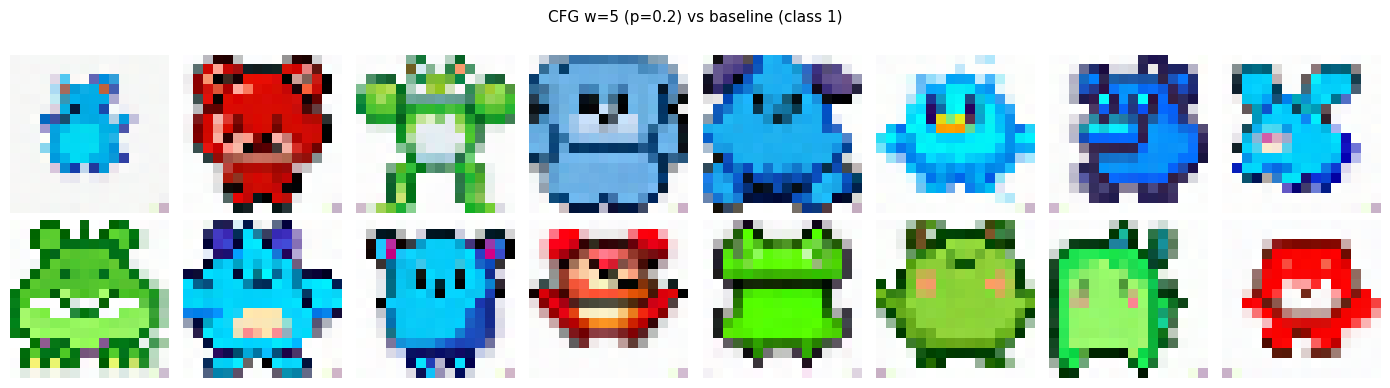

In [39]:
# compare both CFG variants vs baseline conditional model
#baseline is generated once since it doesn't depend on p_uncond
gen_base = sample_class(model, TARGET_CLASS_CFG, n_samples=8)

for P_UNCOND in [0.1, 0.2]:
    cfg_model = cfg_results[P_UNCOND]['model']

    # w=5 chosen as the strongest guidance scale tested
    gen_cfg = sample_cfg(cfg_model, TARGET_CLASS_CFG, guidance_scale=5.0)

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(f'CFG w=5 (p={P_UNCOND}) vs baseline (class {TARGET_CLASS_CFG})', fontsize=11)

    for col in range(8):
        axes[0, col].imshow((gen_base[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu())
        
        axes[0, col].axis('off')
        axes[1, col].imshow((gen_cfg[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu())
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('baseline', fontsize=9, rotation=0, labelpad=55, va='center')
    axes[1, 0].set_ylabel(f'CFG w=5 p={P_UNCOND}', fontsize=9, rotation=0, labelpad=55, va='center')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/cfg_vs_baseline_p{P_UNCOND}.png', dpi=120)
    plt.show()


In [56]:
# prints for CFG val loss for both p_uncond variants
for P_UNCOND in [0.1, 0.2]:
    cfg_model = cfg_results[P_UNCOND]['model']
    cfg_model.eval()
    vloss_cfg = 0.0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)
            # randomly drop labels same as training, to match training distribution
            mask = torch.rand(imgs.size(0), device=DEVICE) < P_UNCOND
            
            lbls_cfg = lbls.clone()
            lbls_cfg[mask] = NULL_CLASS
            noisy, noise = q_sample(imgs, t)
            pred = cfg_model(noisy, t, lbls_cfg)
            vloss_cfg += F.mse_loss(pred, noise).item()
    print(f'CFG p={P_UNCOND} val loss: {vloss_cfg / len(val_loader):.4f}')

CFG p=0.1 val loss: 0.0125
CFG p=0.2 val loss: 0.0116


## 10. Results & Conclusions

In [40]:
for cat in range(NUM_CLASSES):
    for P_UNCOND in [0.1, 0.2]:
        p = Path(f'/kaggle/working/cfg_gen_{P_UNCOND}_{cat}')
        if p.exists():
            shutil.rmtree(p)
            print(f'deleted cfg_gen_{P_UNCOND}_{cat}')

total, used, free = shutil.disk_usage('/kaggle/working')
print(f'free: {free / 1e9:.1f} GB')

import shutil
# compute FID for both CFG variants at guidance scale w=5
cfg_fid_both = {0.1: {}, 0.2: {}}

for P_UNCOND in [0.1, 0.2]:
    cfg_model = cfg_results[P_UNCOND]['model']
    for cat in range(NUM_CLASSES):
        gen_dir = Path(f'/kaggle/working/cfg_gen_{P_UNCOND}_{cat}')
        gen_dir.mkdir(exist_ok=True)
        
        gen = sample_cfg(cfg_model, cat, guidance_scale=5.0, n_samples=N_FID)
        for i, img_t in enumerate(gen):
            img_np = (img_t.clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu().numpy()
            Image.fromarray((img_np*255).astype(np.uint8)).save(gen_dir/f'{i}.png')
        score = cleanfid.compute_fid(str(Path(f'/kaggle/working/fid_real_{cat}')), str(gen_dir))
        
        cfg_fid_both[P_UNCOND][cat] = score
        print(f'p={P_UNCOND} class {cat}: {score:.2f}')

# full comparison table: baseline vs both CFG variants
print('\nFID comparison (lower is better):')

print(f'{"class":<28} baseline   p=0.1   p=0.2')
for cat in range(NUM_CLASSES):
    print(f'{CLASS_NAMES[cat]:<28} {fid_scores[cat]:>8.2f} {cfg_fid_both[0.1][cat]:>7.2f} {cfg_fid_both[0.2][cat]:>7.2f}')

mean_01 = np.mean(list(cfg_fid_both[0.1].values()))
mean_02 = np.mean(list(cfg_fid_both[0.2].values()))



print(f'{"mean":<28} {np.mean(list(fid_scores.values())):>8.2f} {mean_01:>7.2f} {mean_02:>7.2f}')

free: 20.9 GB


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


compute FID between two folders
Found 1000 images in the folder /kaggle/working/fid_real_0


FID fid_real_0 :   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
FID fid_real_0 : 100%|██████████| 32/32 [00:05<00:00,  5.53it/s]


Found 1000 images in the folder /kaggle/working/cfg_gen_0.1_0


...

p=0.2 class 3: 34.38
compute FID between two folders
Found 1000 images in the folder /kaggle/working/fid_real_4


FID fid_real_4 : 100%|██████████| 32/32 [00:12<00:00,  2.66it/s]


Found 1000 images in the folder /kaggle/working/cfg_gen_0.2_4


FID cfg_gen_0.2_4 : 100%|██████████| 32/32 [00:08<00:00,  3.86it/s]


p=0.2 class 4: 37.89

FID comparison (lower is better):
class                        baseline   p=0.1   p=0.2
Characters (no weapon)          18.03   32.70   28.04
Fruits & objects                40.96   52.26   58.19
Large fruits                    29.34   51.27   46.17
Armors & arrows                 31.80   38.42   34.38
Characters (with weapon)        23.08   42.14   37.89
mean                            28.64   43.36   40.93


In [41]:
# full comparison table: baseline vs both CFG variants
print('\nFID comparison (lower is better):')
print(f'{"class":<28} baseline   p=0.1   p=0.2')
for cat in range(NUM_CLASSES):
    print(f'{CLASS_NAMES[cat]:<28} {fid_scores[cat]:>8.2f} {cfg_fid_both[0.1][cat]:>7.2f} {cfg_fid_both[0.2][cat]:>7.2f}')

mean_01 = np.mean(list(cfg_fid_both[0.1].values()))


mean_02 = np.mean(list(cfg_fid_both[0.2].values()))
print(f'{"mean":<28} {np.mean(list(fid_scores.values())):>8.2f} {mean_01:>7.2f} {mean_02:>7.2f}')


FID comparison (lower is better):
class                        baseline   p=0.1   p=0.2
Characters (no weapon)          18.03   32.70   28.04
Fruits & objects                40.96   52.26   58.19
Large fruits                    29.34   51.27   46.17
Armors & arrows                 31.80   38.42   34.38
Characters (with weapon)        23.08   42.14   37.89
mean                            28.64   43.36   40.93


In [42]:
print('\nCFG impact per class (vs baseline):')
print(f'{"class":<28} p=0.1    p=0.2')
for cat in range(NUM_CLASSES):
    delta_01 = fid_scores[cat] - cfg_fid_both[0.1][cat]
    
    delta_02 = fid_scores[cat] - cfg_fid_both[0.2][cat]
    print(f'  {CLASS_NAMES[cat]:<26} {delta_01:+.2f}    {delta_02:+.2f}')

mean_delta_01 = np.mean(list(fid_scores.values())) - np.mean(list(cfg_fid_both[0.1].values()))
mean_delta_02 = np.mean(list(fid_scores.values())) - np.mean(list(cfg_fid_both[0.2].values()))
print(f'  {"mean":<26} {mean_delta_01:+.2f}    {mean_delta_02:+.2f}')


CFG impact per class (vs baseline):
class                        p=0.1    p=0.2
  Characters (no weapon)     -14.67    -10.01
  Fruits & objects           -11.30    -17.22
  Large fruits               -21.93    -16.83
  Armors & arrows            -6.62    -2.59
  Characters (with weapon)   -19.06    -14.81
  mean                       -14.72    -12.29


compute FID between two folders
Found 1000 images in the folder /kaggle/working/fid_real_1


FID fid_real_1 : 100%|██████████| 32/32 [00:11<00:00,  2.74it/s]


Found 1000 images in the folder /kaggle/working/cfg_scale_0.1_1.0


FID cfg_scale_0.1_1.0 : 100%|██████████| 32/32 [00:08<00:00,  3.95it/s]


p=0.1 w=1.0: FID=37.80
compute FID between two folders
Found 1000 images in the folder /kaggle/working/fid_real_1


...

p=0.2 w=3.0: FID=48.16
compute FID between two folders
Found 1000 images in the folder /kaggle/working/fid_real_1


FID fid_real_1 : 100%|██████████| 32/32 [00:08<00:00,  3.62it/s]


Found 1000 images in the folder /kaggle/working/cfg_scale_0.2_5.0


FID cfg_scale_0.2_5.0 : 100%|██████████| 32/32 [00:07<00:00,  4.36it/s]


p=0.2 w=5.0: FID=55.50


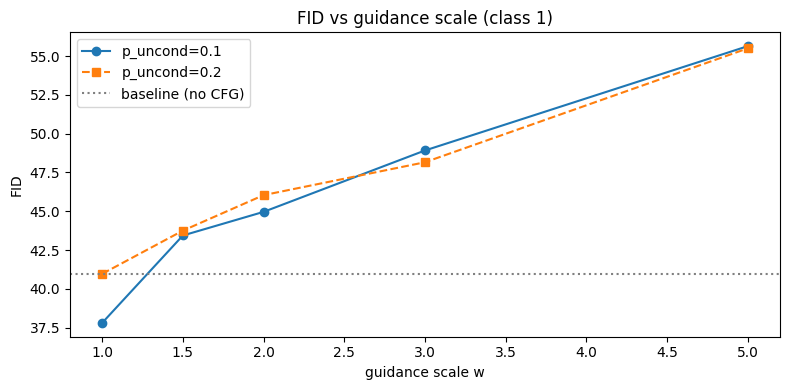

In [44]:
# compute FID at each guidance scale for both p_uncond values
# shows whether any guidance scale recovers baseline quality
scales = [1.0, 1.5, 2.0, 3.0, 5.0]
scale_fids = {0.1: [], 0.2: []}

for P_UNCOND in [0.1, 0.2]:
    cfg_model = cfg_results[P_UNCOND]['model']
    for w in scales:
        gen_dir = Path(f'/kaggle/working/cfg_scale_{P_UNCOND}_{w}')
        
        gen_dir.mkdir(exist_ok=True)

        # use class 1 (fruits) consistently across all scale experiments
        gen = sample_cfg(cfg_model, TARGET_CLASS_CFG, guidance_scale=w, n_samples=N_FID)
        for i, img_t in enumerate(gen):
            img_np = (img_t.clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu().numpy()
            Image.fromarray((img_np*255).astype(np.uint8)).save(gen_dir / f'{i}.png')

        fid = cleanfid.compute_fid(str(Path(f'/kaggle/working/fid_real_{TARGET_CLASS_CFG}')), str(gen_dir))
        scale_fids[P_UNCOND].append(fid)
        print(f'p={P_UNCOND} w={w}: FID={fid:.2f}')

# plot both curves + baseline for reference
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scales, scale_fids[0.1], 'o-', label='p_uncond=0.1')
ax.plot(scales, scale_fids[0.2], 's--', label='p_uncond=0.2')

# baseline FID for class 1 as reference line
ax.axhline(y=fid_scores[TARGET_CLASS_CFG], color='gray',
           linestyle=':', label='baseline (no CFG)')

ax.set_xlabel('guidance scale w')
ax.set_ylabel('FID')
ax.set_title(f'FID vs guidance scale (class {TARGET_CLASS_CFG})')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/cfg_fid_curve.png', dpi=120)
plt.show()
# if both curves stay above the baseline dotted line at all scales,CFG does not improve generation for this model regardless of p_uncond or w

In [45]:
print('final results:')
print(f'params: {total_params/1e6:.2f}M, res: {IMG_SIZE}x{IMG_SIZE}, T={T}, epochs={EPOCHS}')
print(f'train loss: {train_losses[-1]:.4f} | val loss: {val_losses[-1]:.4f}')

print('FID:')
for cat, score in fid_scores.items():
    print(f'{cat} , {CLASS_NAMES[cat]}: {score:.2f}')
print(f'mean:{np.mean(list(fid_scores.values())):.2f}')

final results:
params: 4.99M, res: 16x16, T=300, epochs=100
train loss: 0.0117 | val loss: 0.0116
FID:
0 , Characters (no weapon): 18.03
1 , Fruits & objects: 40.96
2 , Large fruits: 29.34
3 , Armors & arrows: 31.80
4 , Characters (with weapon): 23.08
mean:28.64


In [46]:
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses':train_losses, 
    'val_losses': val_losses,
    'fid_scores':fid_scores,
    'config': dict(T=T, img_size=IMG_SIZE,base_ch=64,time_dim=128,num_classes=NUM_CLASSES, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE)},
    '/kaggle/working/conditional_diffusion_final.pt')
print('saved to /kaggle/working/conditional_diffusion_final.pt')

saved to /kaggle/working/conditional_diffusion_final.pt


model loaded
train loss: 0.0117, val loss: 0.0116
generating class 0...


generating class 1...


generating class 2...


generating class 3...


generating class 4...


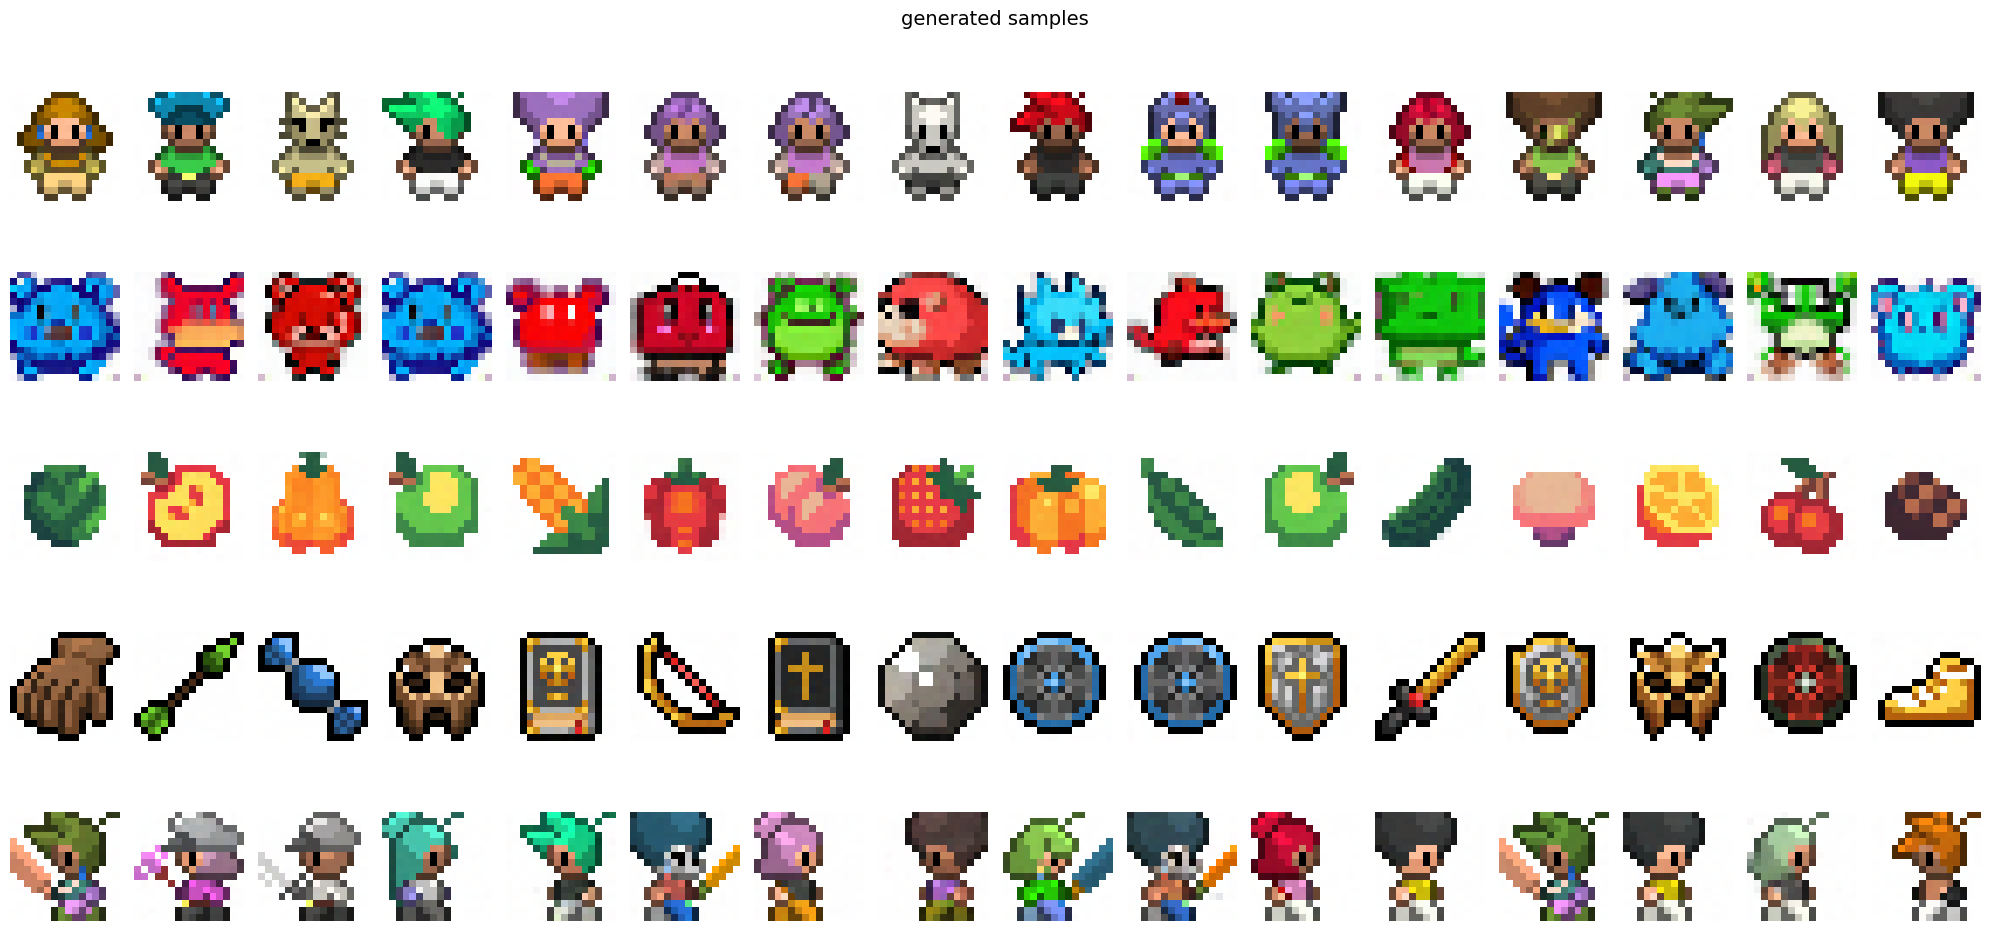

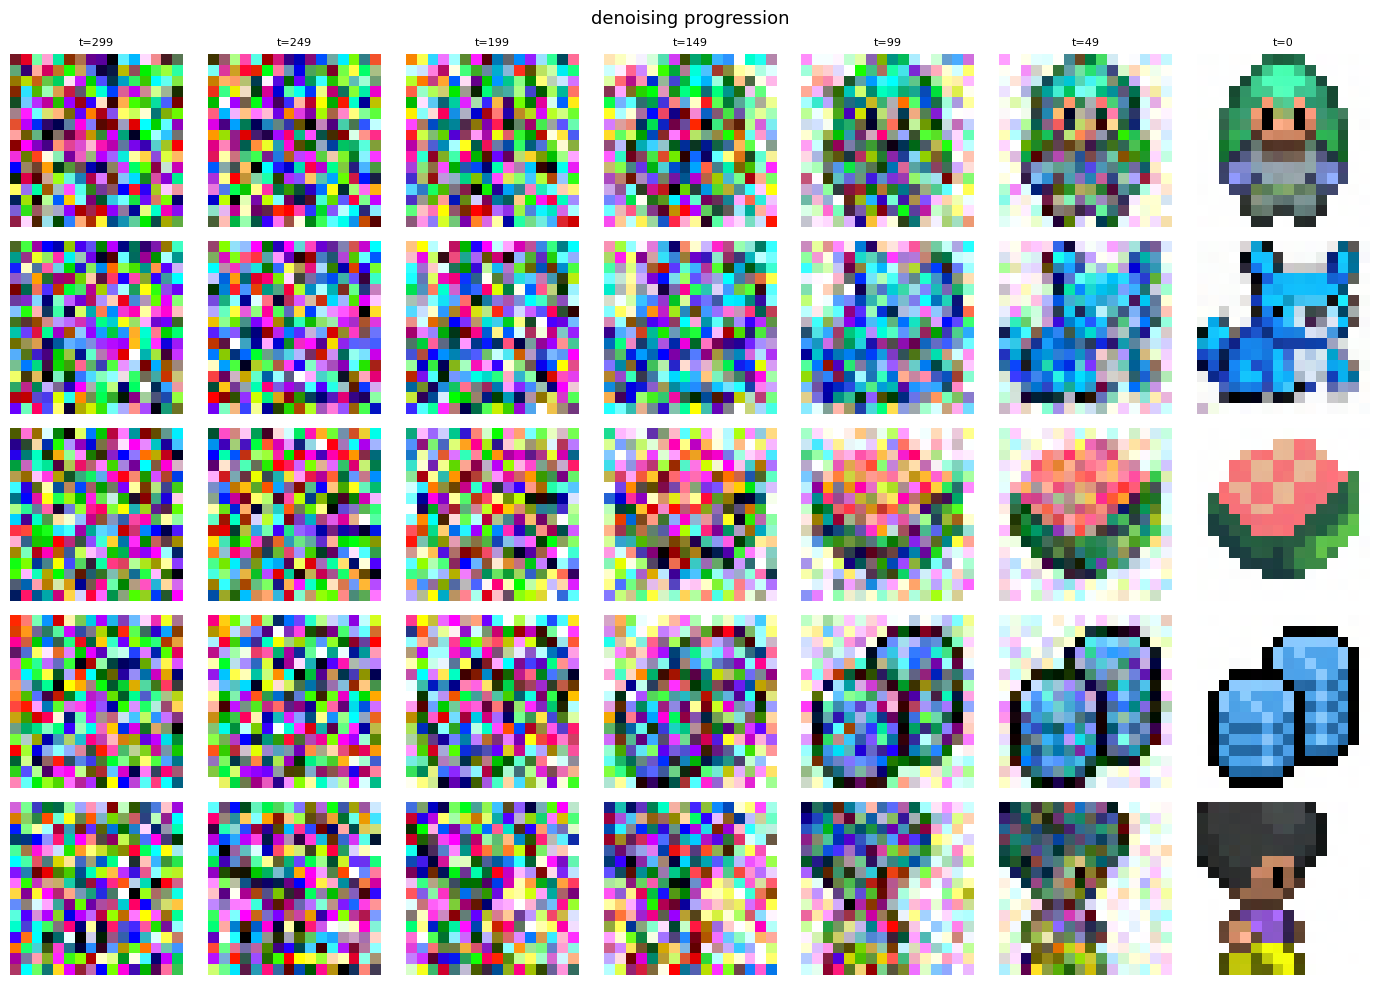


FID from checkpoint:
  0 - Characters (no weapon): 18.03
  1 - Fruits & objects: 40.96
  2 - Large fruits: 29.34
  3 - Armors & arrows: 31.80
  4 - Characters (with weapon): 23.08
  mean: 28.64


In [47]:
#relooad final model & generate results
import torch, math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#load checkpoint saved at end of training
ckpt=torch.load('/kaggle/working/conditional_diffusion_final.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print('model loaded')
print(f'train loss: {ckpt["train_losses"][-1]:.4f}, val loss: {ckpt["val_losses"][-1]:.4f}')

# generate 16 samples per category
fig, axes = plt.subplots(NUM_CLASSES, 16, figsize=(20, NUM_CLASSES*2))
fig.suptitle('generated samples', fontsize=14)
for cat in range(NUM_CLASSES):
    print(f'generating class {cat}...')
    gen = sample_class(model, class_label=cat, n_samples=16)
    for col in range(16):
        img = (gen[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu()
        
        axes[cat, col].imshow(img)
        axes[cat, col].axis('off')
    
    axes[cat, 0].set_ylabel(CLASS_NAMES[cat], fontsize=8,rotation=0, labelpad=90, va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/final_results.png', dpi=120)
plt.show()

@torch.no_grad()
def sample_with_progression(model, class_label, n_snapshots=7):
    model.eval()
    #shows how the image gradually emerges from noise during the reverse process
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    snapshots = []
    snap_steps = torch.linspace(T-1, 0, n_snapshots).long().tolist()
    snap_set = set(snap_steps)
    for t_val in reversed(range(T)):
        x = p_sample(model, x, t_val, class_label)
        if t_val in snap_set:
            snapshots.append((t_val, x.clone()))
    return snapshots
# visualize denoising progression for one sample per class
fig, axes = plt.subplots(NUM_CLASSES, 7, figsize=(14, NUM_CLASSES*2))
fig.suptitle('denoising progression', fontsize=13)
for cat in range(NUM_CLASSES):
    snaps = sample_with_progression(model, class_label=cat)
    for col, (t_val, img_t) in enumerate(snaps):
        img = (img_t[0].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu()
        axes[cat, col].imshow(img)
        
        axes[cat, col].axis('off')
        if cat == 0:
            axes[cat, col].set_title(f't={t_val}',fontsize=8)
    axes[cat, 0].set_ylabel(CLASS_NAMES[cat], fontsize=7,  rotation=0, labelpad=90, va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/denoising_progression.png', dpi=120)
plt.show()

if 'fid_scores' in ckpt:
    print('\nFID from checkpoint:')
    for cat, score in ckpt['fid_scores'].items():
        print(f'  {cat} - {CLASS_NAMES[int(cat)]}: {score:.2f}')
    print(f'  mean: {np.mean(list(ckpt["fid_scores"].values())):.2f}')

In [58]:
# Summary of all final losses
print('=== Final Loss Summary ===')

print(f'Conditional    — train: {train_losses[-1]:.4f} | val: {val_losses[-1]:.4f}')

print(f'Unconditional  — val:   {uncond_val_loss:.4f}')
for P_UNCOND in [0.1, 0.2]:
    final_train = cfg_results[P_UNCOND]['losses'][-1]
    print(f'CFG p={P_UNCOND}      — train: {final_train:.4f}')

=== Final Loss Summary ===
Conditional    — train: 0.0117 | val: 0.0116
Unconditional  — val:   0.0128
CFG p=0.1      — train: 0.0120
CFG p=0.2      — train: 0.0119


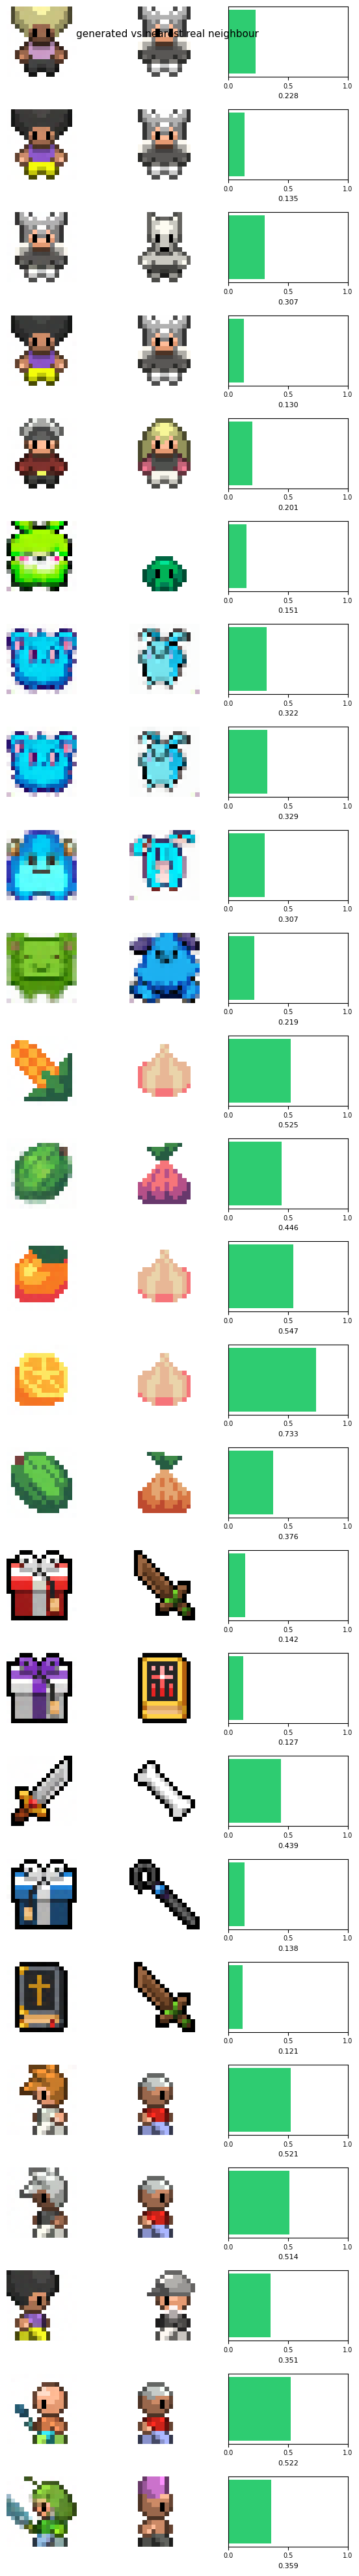

similarity summary: 
  0 - Characters (no weapon): 0.200 (ok)
  1 - Fruits & objects: 0.266 (ok)
  2 - Large fruits: 0.525 (ok)
  3 - Armors & arrows: 0.194 (ok)
  4 - Characters (with weapon): 0.453 (ok)


In [48]:
# nearest neighbour analysis- checks whether the model memorized training images
##high cosine similarity (>0.95) between generated and real images suggests overfitting
from torch.nn.functional import cosine_similarity

def find_nearest_real(gen_img, sprites, label_indices, cat):
    # cosine similarity measures angle between vectors, not pixel-wise distance
    gen_flat = gen_img.clamp(-1,1).cpu().flatten().unsqueeze(0)
    cat_sprites = sprites[label_indices == cat]
    #normalizing real sprites to [-1,1] to match generated image range
    real_flat = torch.from_numpy(cat_sprites.astype(np.float32) / 127.5 - 1.0).reshape(len(cat_sprites), -1)
    sims = cosine_similarity(gen_flat, real_flat)
    best_idx = sims.argmax().item()
    return cat_sprites[best_idx], sims[best_idx].item()

N_TEST = 5
fig, axes = plt.subplots(NUM_CLASSES * N_TEST, 3, figsize=(6, NUM_CLASSES * N_TEST * 1.6))
fig.suptitle('generated vs nearest real neighbour', fontsize=11)

row = 0
avg_sims = {}
for cat in range(NUM_CLASSES):
    gen = sample_class(model, class_label=cat, n_samples=N_TEST)
    cat_sims = []
    for i in range(N_TEST):
        nearest, sim = find_nearest_real(gen[i], sprites, label_indices, cat)
        cat_sims.append(sim)

        axes[row,0].imshow((gen[i].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu())
        axes[row,0].axis('off')
        if i == 0:
            axes[row, 0].set_ylabel(CLASS_NAMES[cat], fontsize=7,
                                    rotation=0, labelpad=100, va='center')
        axes[row,1].imshow(nearest)
        axes[row,1].axis('off')
        # color encodes memorization risk:
        # red >0.95 = likely memorized, orange >0.80 = borderline, green = ok
        color = '#e74c3c' if sim > 0.95 else '#f39c12' if sim > 0.80 else '#2ecc71'
        axes[row,2].barh([0], [sim], color=color, height=0.5)
        
        axes[row,2].set_xlim(0,1)
        axes[row,2].set_xticks([0,0.5,1.0])
        axes[row,2].set_yticks([])
        axes[row,2].set_xlabel(f'{sim:.3f}', fontsize=8)
        
        axes[row,2].tick_params(labelsize=7)
        row += 1
    
    avg_sims[cat] = np.mean(cat_sims)

plt.tight_layout()
plt.savefig('/kaggle/working/nearest_neighbour_analysis.png', dpi=120)
plt.show()
# summary: average similarity per class

print('similarity summary: ')
for cat, avg in avg_sims.items():
    status = 'overfit' if avg > 0.95 else 'borderline' if avg > 0.80 else 'ok'
    print(f'  {cat} - {CLASS_NAMES[cat]}: {avg:.3f} ({status})')